# Modeling — **SVM + TF-IDF**  (sumber: MongoDB Atlas)

Self-contained. Baca **`processed_svm`** (kolom `svm`,`label_id`,`split`), latih
**TF-IDF → LinearSVC**, evaluasi di **test set** (identik dgn IndoBERT → perbandingan adil).

Isi notebook: tuning di val (`PredefinedSplit`) → refit train+val → **evaluasi test**
→ **interpretasi (top fitur/kelas)** → **analisis error** → **kerangka perbandingan**.

## 0. Dependency

In [1]:
%pip install -q "pymongo[srv]" dnspython certifi python-dotenv scikit-learn matplotlib joblib pandas numpy

Note: you may need to restart the kernel to use updated packages.


## 1. Baca `processed_svm` dari MongoDB

In [2]:
import os, pandas as pd
from pymongo import MongoClient
import certifi
MONGO_URI=os.environ.get("MONGO_URI","")
if not MONGO_URI:
    try:
        from dotenv import load_dotenv; load_dotenv(); MONGO_URI=os.environ.get("MONGO_URI","")
    except Exception: pass
if not MONGO_URI:
    from getpass import getpass; MONGO_URI=getpass("MONGO_URI: ")
DB=os.environ.get("MONGO_DB_NAME","youtube_sentiment")
client=MongoClient(MONGO_URI,tlsCAFile=certifi.where(),serverSelectionTimeoutMS=20000)
client.admin.command("ping"); print("Koneksi MongoDB OK.")
LABELS=["Negatif","Netral","Positif"]
df=pd.DataFrame(list(client[DB]["processed_svm"].find({},
    {"_id":0,"svm":1,"text":1,"label_id":1,"label":1,"split":1})))
d_tr=df[df.split=="train"].reset_index(drop=True)
d_va=df[df.split=="val"].reset_index(drop=True)
d_te=df[df.split=="test"].reset_index(drop=True)
print(f"train={len(d_tr)} val={len(d_va)} test={len(d_te)}")

Koneksi MongoDB OK.


train=2098 val=600 test=300


## 2. Pipeline + tuning di val (PredefinedSplit)

In [3]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit
SEED=42; TEXT="svm"; LAB="label_id"
def build():
    return Pipeline([("tfidf",TfidfVectorizer(sublinear_tf=True)),
                     ("clf",LinearSVC(class_weight="balanced",random_state=SEED))])
X=pd.concat([d_tr[TEXT],d_va[TEXT]],ignore_index=True)
y=pd.concat([d_tr[LAB],d_va[LAB]],ignore_index=True)
ps=PredefinedSplit(np.r_[np.full(len(d_tr),-1),np.zeros(len(d_va))])
grid={"tfidf__ngram_range":[(1,1),(1,2)],"tfidf__min_df":[1,2,3],"clf__C":[0.1,0.5,1.0,2.0]}
gs=GridSearchCV(build(),grid,scoring="f1_macro",cv=ps,n_jobs=-1,verbose=0); gs.fit(X,y)
print("Param terbaik:",gs.best_params_,"| val macro-F1=%.4f"%gs.best_score_)

Param terbaik: {'clf__C': 0.1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)} | val macro-F1=0.6246


### Hasil grid search (top konfigurasi di val)

In [4]:
res=pd.DataFrame(gs.cv_results_)
cols={"param_clf__C":"C","param_tfidf__ngram_range":"ngram","param_tfidf__min_df":"min_df","mean_test_score":"val_macroF1"}
res=res[list(cols)].rename(columns=cols).sort_values("val_macroF1",ascending=False)
res["val_macroF1"]=res["val_macroF1"].round(4); res.head(8).reset_index(drop=True)

,C,ngram,min_df,val_macroF1
0,0.1,"(1, 2)",2,0.6246
1,0.1,"(1, 2)",3,0.6203
2,0.1,"(1, 1)",3,0.6181
3,0.1,"(1, 1)",2,0.6170
4,0.1,"(1, 2)",1,0.6142
5,0.1,"(1, 1)",1,0.6125
6,0.5,"(1, 2)",2,0.6067
7,0.5,"(1, 2)",1,0.6046


## 3. Refit model terbaik di train+val

In [5]:
best=build().set_params(**gs.best_params_); best.fit(X,y)
print("Refit pada train+val:",len(X),"dok")

Refit pada train+val: 2698 dok


## 4. Evaluasi di test set

In [6]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix
def evaluate(yt,yp,labels=LABELS):
    ids=list(range(len(labels)))
    rep=classification_report(yt,yp,labels=ids,target_names=labels,output_dict=True,zero_division=0)
    return {"accuracy":round(accuracy_score(yt,yp),4),
            "macro_f1":round(f1_score(yt,yp,average="macro",zero_division=0),4),
            "weighted_f1":round(f1_score(yt,yp,average="weighted",zero_division=0),4),
            "per_class":{l:{k:round(rep[l][k],4) for k in["precision","recall","f1-score"]}|{"support":int(rep[l]["support"])} for l in labels},
            "confusion_matrix":confusion_matrix(yt,yp,labels=ids).tolist(),"labels":labels}
def report(m,title):
    print("="*58);print(" ",title);print("="*58)
    print(f"  Accuracy {m['accuracy']:.4f} | Macro-F1 {m['macro_f1']:.4f} | Weighted-F1 {m['weighted_f1']:.4f}\n")
    print(f"  {'Kelas':<10}{'Prec':>8}{'Recall':>8}{'F1':>8}{'Sup':>6}")
    for l in m["labels"]:
        p=m["per_class"][l]; print(f"  {l:<10}{p['precision']:>8.3f}{p['recall']:>8.3f}{p['f1-score']:>8.3f}{p['support']:>6d}")
yhat_te=list(best.predict(d_te[TEXT])); yhat_va=list(best.predict(d_va[TEXT]))
m_test=evaluate(d_te[LAB].tolist(),yhat_te); m_val=evaluate(d_va[LAB].tolist(),yhat_va)
report(m_test,"SVM + TF-IDF — TEST")

  SVM + TF-IDF — TEST
  Accuracy 0.6933 | Macro-F1 0.6944 | Weighted-F1 0.6944

  Kelas         Prec  Recall      F1   Sup
  Negatif      0.787   0.740   0.763   100
  Netral       0.627   0.690   0.657   100
  Positif      0.677   0.650   0.663   100


## 5. Confusion matrix

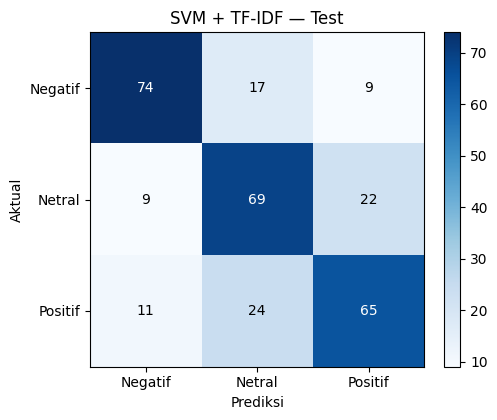

In [7]:
import matplotlib.pyplot as plt
cm=np.array(m_test["confusion_matrix"])
fig,ax=plt.subplots(figsize=(5,4.3)); im=ax.imshow(cm,cmap="Blues")
ax.set_xticks(range(3),LABELS); ax.set_yticks(range(3),LABELS)
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual"); ax.set_title("SVM + TF-IDF — Test")
th=cm.max()/2
for i in range(3):
    for j in range(3): ax.text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>th else "black")
fig.colorbar(im,ax=ax,fraction=0.046); fig.tight_layout(); plt.show()

## 6. Interpretasi — fitur (kata) paling berpengaruh per kelas

Koefisien LinearSVC (one-vs-rest) atas fitur TF-IDF: nilai positif besar = pendorong kuat kelas itu.

In [8]:
vec=best.named_steps["tfidf"]; clf=best.named_steps["clf"]
feats=np.array(vec.get_feature_names_out()); coef=clf.coef_   # (3, n_feat)
for i,l in enumerate(LABELS):
    top=np.argsort(coef[i])[::-1][:15]
    print(f"[{l}] " + ", ".join(feats[top]))

[Negatif] panci, roy, gila, penjara, benci, pak jokowi, fitnah, suryo, tompel, ana, gerombol, malu, orang, ibu, sakit
[Netral] siapa, vs, putus, adu, host, asli palsu, gogon, masalah, adil, politik, bingung, pa, hotman, kaya, netral
[Positif] palsu, jokowi, bohong, ijazah, ugm, pak roy, rektor, takut, mulyono, asli, rrt, tutup, tunjuk, semangat, rakyat


## 7. Analisis error — contoh komentar salah klasifikasi

In [9]:
d_te=d_te.copy(); d_te["pred_id"]=yhat_te
d_te["pred"]=d_te["pred_id"].map({i:l for i,l in enumerate(LABELS)})
err=d_te[d_te["label_id"]!=d_te["pred_id"]]
print(f"Salah klasifikasi: {len(err)}/{len(d_te)} ({len(err)/len(d_te)*100:.1f}%)\n")
print("Pola kesalahan (aktual -> prediksi):")
print(err.groupby(["label","pred"]).size().sort_values(ascending=False).head(6).to_string())
print("\nContoh (maks 8):")
import pandas as pd; pd.set_option("display.max_colwidth",70)
for _,r in err.sample(min(8,len(err)),random_state=1).iterrows():
    print(f"  [aktual={r['label']} | pred={r['pred']}] {r['text'][:80]!r}")

Salah klasifikasi: 92/300 (30.7%)

Pola kesalahan (aktual -> prediksi):
label    pred   
Positif  Netral     24
Netral   Positif    22
Negatif  Netral     17
Positif  Negatif    11
Negatif  Positif     9
Netral   Negatif     9

Contoh (maks 8):
  [aktual=Negatif | pred=Positif] 'Paling berkelas..bung refli harun'
  [aktual=Netral | pred=Positif] 'Omaga bung aiman sampai emosi ternak mulyono enggk ada yang nyambung'
  [aktual=Negatif | pred=Netral] 'Wahai para sebangsa setanah airmari kita belajar berfikir secara dewasa dan nurm'
  [aktual=Negatif | pred=Netral] 'stasiun tv, udh jangan di tampilkan ...lah'
  [aktual=Negatif | pred=Netral] 'Refly gunakan pasal yg lama soalnya pasal yg baru yg berlaku saat ini tidak meng'
  [aktual=Netral | pred=Negatif] 'Orang ini grocos aja.'
  [aktual=Negatif | pred=Positif] 'Benar sekali Ibu yg berkerudung Hijau,Mereka2 ini Roy Suryo Tifa dan Rismon dkk '
  [aktual=Negatif | pred=Netral] 'Keren pak hakim😂😂'


## 8. Simpan model & metrik

In [10]:
import json,joblib,pathlib
ROOT=pathlib.Path.cwd()
for _p in [ROOT,*ROOT.parents]:
    if (_p/"configs").exists() or (_p/".git").exists(): ROOT=_p; break
MODELS=ROOT/"outputs"/"models"; REPORTS=ROOT/"outputs"/"reports"
MODELS.mkdir(parents=True,exist_ok=True); REPORTS.mkdir(parents=True,exist_ok=True)
joblib.dump(best,MODELS/"svm_tfidf.joblib")
json.dump({"model":"SVM+TF-IDF","best_params":{k:str(v) for k,v in gs.best_params_.items()},
           "val":m_val,"test":m_test},open(REPORTS/"svm_metrics.json","w"),ensure_ascii=False,indent=2)
fig.savefig(REPORTS/"svm_test_confusion.png",dpi=120)
print("Tersimpan ke",REPORTS)

Tersimpan ke /home/ravi/Projects/jokowi_sentiment_project/outputs/reports


## 9. Kerangka perbandingan SVM vs IndoBERT

Begitu IndoBERT selesai di Colab dan `outputs/reports/indobert_metrics.json` tersedia,
sel ini menampilkan tabel + grafik perbandingan. Kalau belum ada, hanya SVM yg tampil.


Model              Acc  MacroF1   WtdF1
SVM+TF-IDF       0.693    0.694   0.694
IndoBERT         0.660    0.659   0.659


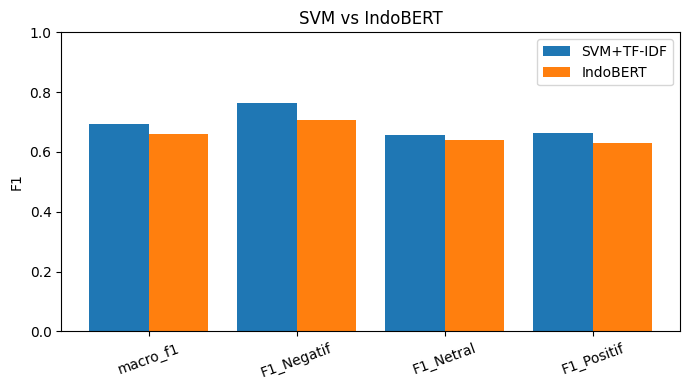

In [11]:
import json,pathlib,numpy as np,matplotlib.pyplot as plt
REP=ROOT/"outputs"/"reports"
rows={"SVM+TF-IDF":json.load(open(REP/"svm_metrics.json"))["test"]}
ib=REP/"indobert_metrics.json"
if ib.exists():
    rows["IndoBERT"]=json.load(open(ib))["test"]
else:
    print("(indobert_metrics.json belum ada — jalankan notebook IndoBERT di Colab lalu taruh di outputs/reports/)")
print(f"\n{'Model':<14}{'Acc':>8}{'MacroF1':>9}{'WtdF1':>8}")
for n,m in rows.items():
    print(f"{n:<14}{m['accuracy']:>8.3f}{m['macro_f1']:>9.3f}{m['weighted_f1']:>8.3f}")
# grafik macro-F1 + F1 per kelas
import numpy as np
labels=["macro_f1"]+[f"F1_{l}" for l in LABELS]
def vals(m): return [m["macro_f1"]]+[m["per_class"][l]["f1-score"] for l in LABELS]
x=np.arange(len(labels)); w=0.8/max(len(rows),1)
fig2,ax=plt.subplots(figsize=(7,4))
for k,(n,m) in enumerate(rows.items()): ax.bar(x+k*w,vals(m),w,label=n)
ax.set_xticks(x+w*(len(rows)-1)/2,labels,rotation=20); ax.set_ylim(0,1); ax.set_ylabel("F1"); ax.legend(); ax.set_title("SVM vs IndoBERT")
fig2.tight_layout(); plt.show()

**Lanjut:** jalankan `indobert_finetune_colab.ipynb` (Colab/GPU), simpan `indobert_metrics.json` ke `outputs/reports/`, lalu jalankan ulang sel #9 untuk perbandingan final.